Ciclo Crisis 52-55 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)


Verificación de porcentajes:
año
1980    101.0
1981    101.0
1982    100.0
1983     99.0
1984    100.0
dtype: float64


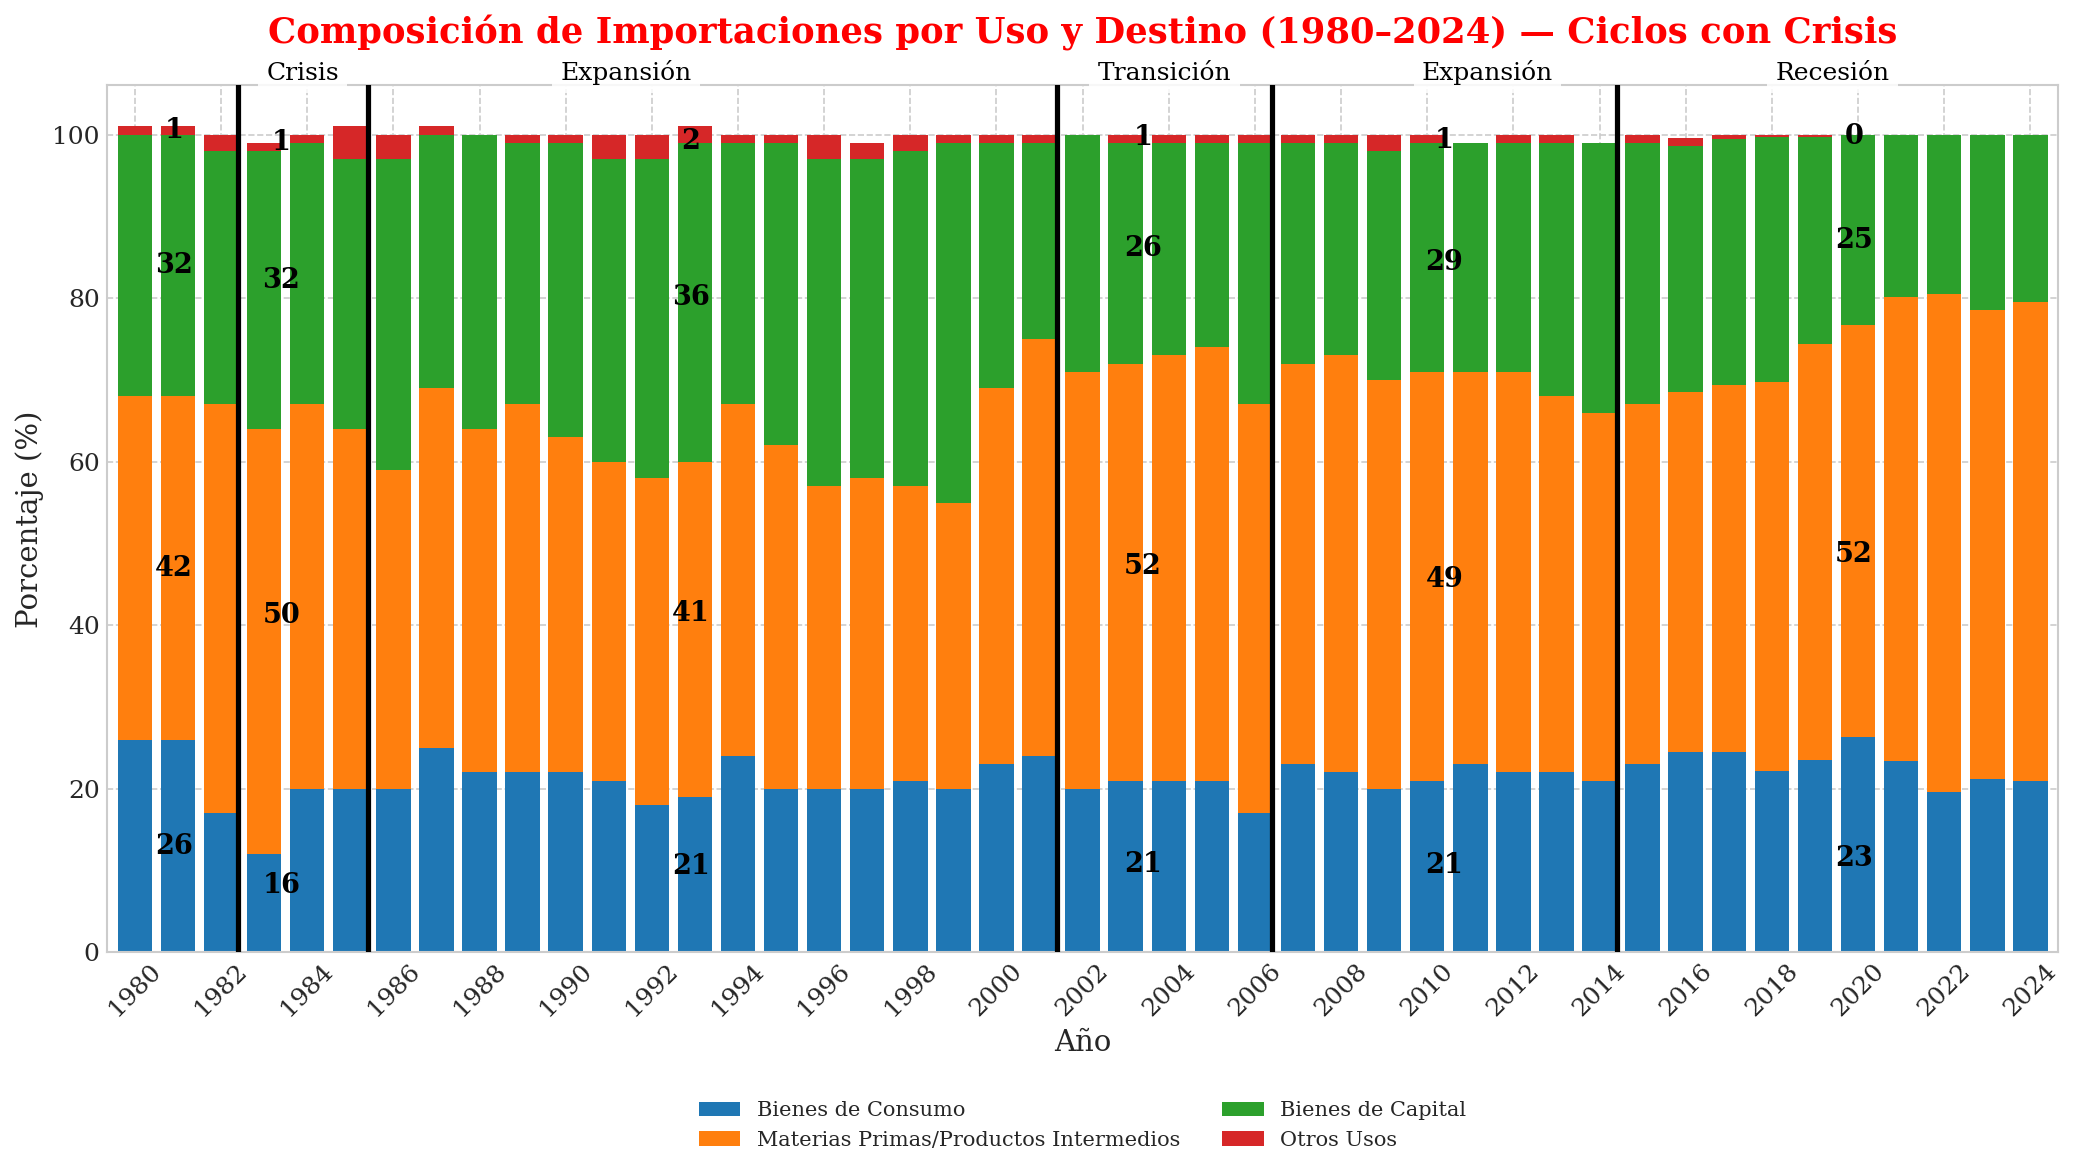

Gráfico guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/participacion_composicion_importaciones_uso_destino/participacion_composicion_importaciones_uso_destino_ciclos.png


In [1]:
# ═══════════════════════════════════════════════════════════════════
# PRIMERA GRÁFICA: CICLOS CON CRISIS - BARPLOT
# ═══════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os
import numpy as np
import sys

from func_auxiliares.config import *
from func_auxiliares.graficos_utils import (
    set_style,
    plot_stacked_bar,            # Función principal para barras apiladas
    add_hitos_barras,            # Hitos específicos para barplot
    add_cycle_means_barras,      # Medias por ciclo para barplot
    adjust_cycles,
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
OUTPUT_DIR = ASSETS_DIR / "serie_completa" / "participacion_composicion_importaciones_uso_destino"
os.makedirs(OUTPUT_DIR, exist_ok=True)
set_style()

# ───────────────────────── 2. CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = pd.read_sql_query("SELECT * FROM participacion_composicion_importaciones_uso_destino", conn)

df.set_index("año", inplace=True)

# ──────────────── 3. COMPONENTES Y PREPARACIÓN ──────────────────────
# Los datos ya están en porcentaje según la documentación
# Ignoramos la columna 'total_cif' como indicó el usuario
componentes = [
    ("bienes_consumo", "Bienes de Consumo"),
    ("materias_primas_productos_intermedios", "Materias Primas/Productos Intermedios"),
    ("bienes_capital", "Bienes de Capital"),
    ("diversos", "Otros Usos"),
]

# Extraer columnas para cálculos
cols = [col for col, _ in componentes]

# Verificación: cada fila debe sumar 100% (sin incluir total_cif)
print("Verificación de porcentajes:")
print(df[cols].sum(axis=1).round(2).head())  # Debe mostrar ~100.0 para cada año

# ──────────────── 4. PREPARACIÓN DE CICLOS Y PERÍODOS ────────────────
cycles_adj = adjust_cycles(df, CYCLES)

# Calcular estadísticas por ciclo (sobre porcentajes)
cycle_stats = {
    name: df.loc[sl, cols].mean().to_dict()
    for name, sl in cycles_adj.items()
}

# ───────────── 5. OFFSETS Y UTILIDADES (POSICIONAMIENTO) ────────────
# Offsets para hitos verticales en barplot
hitos_offset = {
    1952: (0, 1),     # (desplazamiento_x, altura_relativa)
    1956: (0, 1),
    1970: (0, 1),
    1982: (0, 1),
    1985: (0, 1),
    2001: (0, 1),
    2006: (0, 1),
    2014: (0, 1)
}

# Posición horizontal del texto de hitos
hitos_text_x = {
    1952: 2,
    1956: 6,
    1970: 5,
    1982: 1.5,
    1985: 6,
    2001: 2.5,
    2006: 5,
    2014: 5
}

# Offsets para medias por ciclo (específico por ciclo y componente)
MEAN_OFFSETS_BY_NAME = {

}

# ────────────────────────── 6. GRÁFICO BASE ──────────────────────────
fig, ax = plot_stacked_bar(
    df[cols],                     # DataFrame con porcentajes
    series=componentes,           # Lista de tuplas (columna, etiqueta)
    title=f"Composición de Importaciones por Uso y Destino ({df.index.min()}–{df.index.max()}) — Ciclos con Crisis",
    legend_ncol=2,               # Número de columnas en la leyenda
    figsize=(14, 8),             # Tamaño de la figura
    xlabel="Año",
    ylabel="Porcentaje (%)"
)

# ────────────────────── 7. ELEMENTOS GRÁFICOS ADICIONALES ────────────
# Líneas verticales de hitos (específicas para barplot)
add_hitos_barras(
    ax, 
    df.index,           # Índice temporal (años)
    hitos_v,            # Diccionario de hitos de config.py
    hitos_offset,       # Offsets verticales
    hitos_text_x        # Posiciones horizontales del texto
)

# Medias por ciclo (específicas para barplot)
add_cycle_means_barras(
    ax,
    index=list(df.index),        # Secuencia de años
    cycle_slices=cycles_adj,     # Diccionario nombre → slice
    cycle_stats=cycle_stats,     # Diccionario nombre → {col: media}
    cols=cols,                   # Orden de apilado de componentes
    offsets=MEAN_OFFSETS_BY_NAME,  # Offsets específicos
)

# ────────────────────────── 8. FINALIZACIÓN ──────────────────────────
plt.tight_layout()

# Guardar en formato PNG de alta resolución
out_path = os.path.join(OUTPUT_DIR, "participacion_composicion_importaciones_uso_destino_ciclos.png")
plt.savefig(out_path, dpi=300)
plt.show()
plt.close()

print(f"Gráfico guardado en: {out_path}")

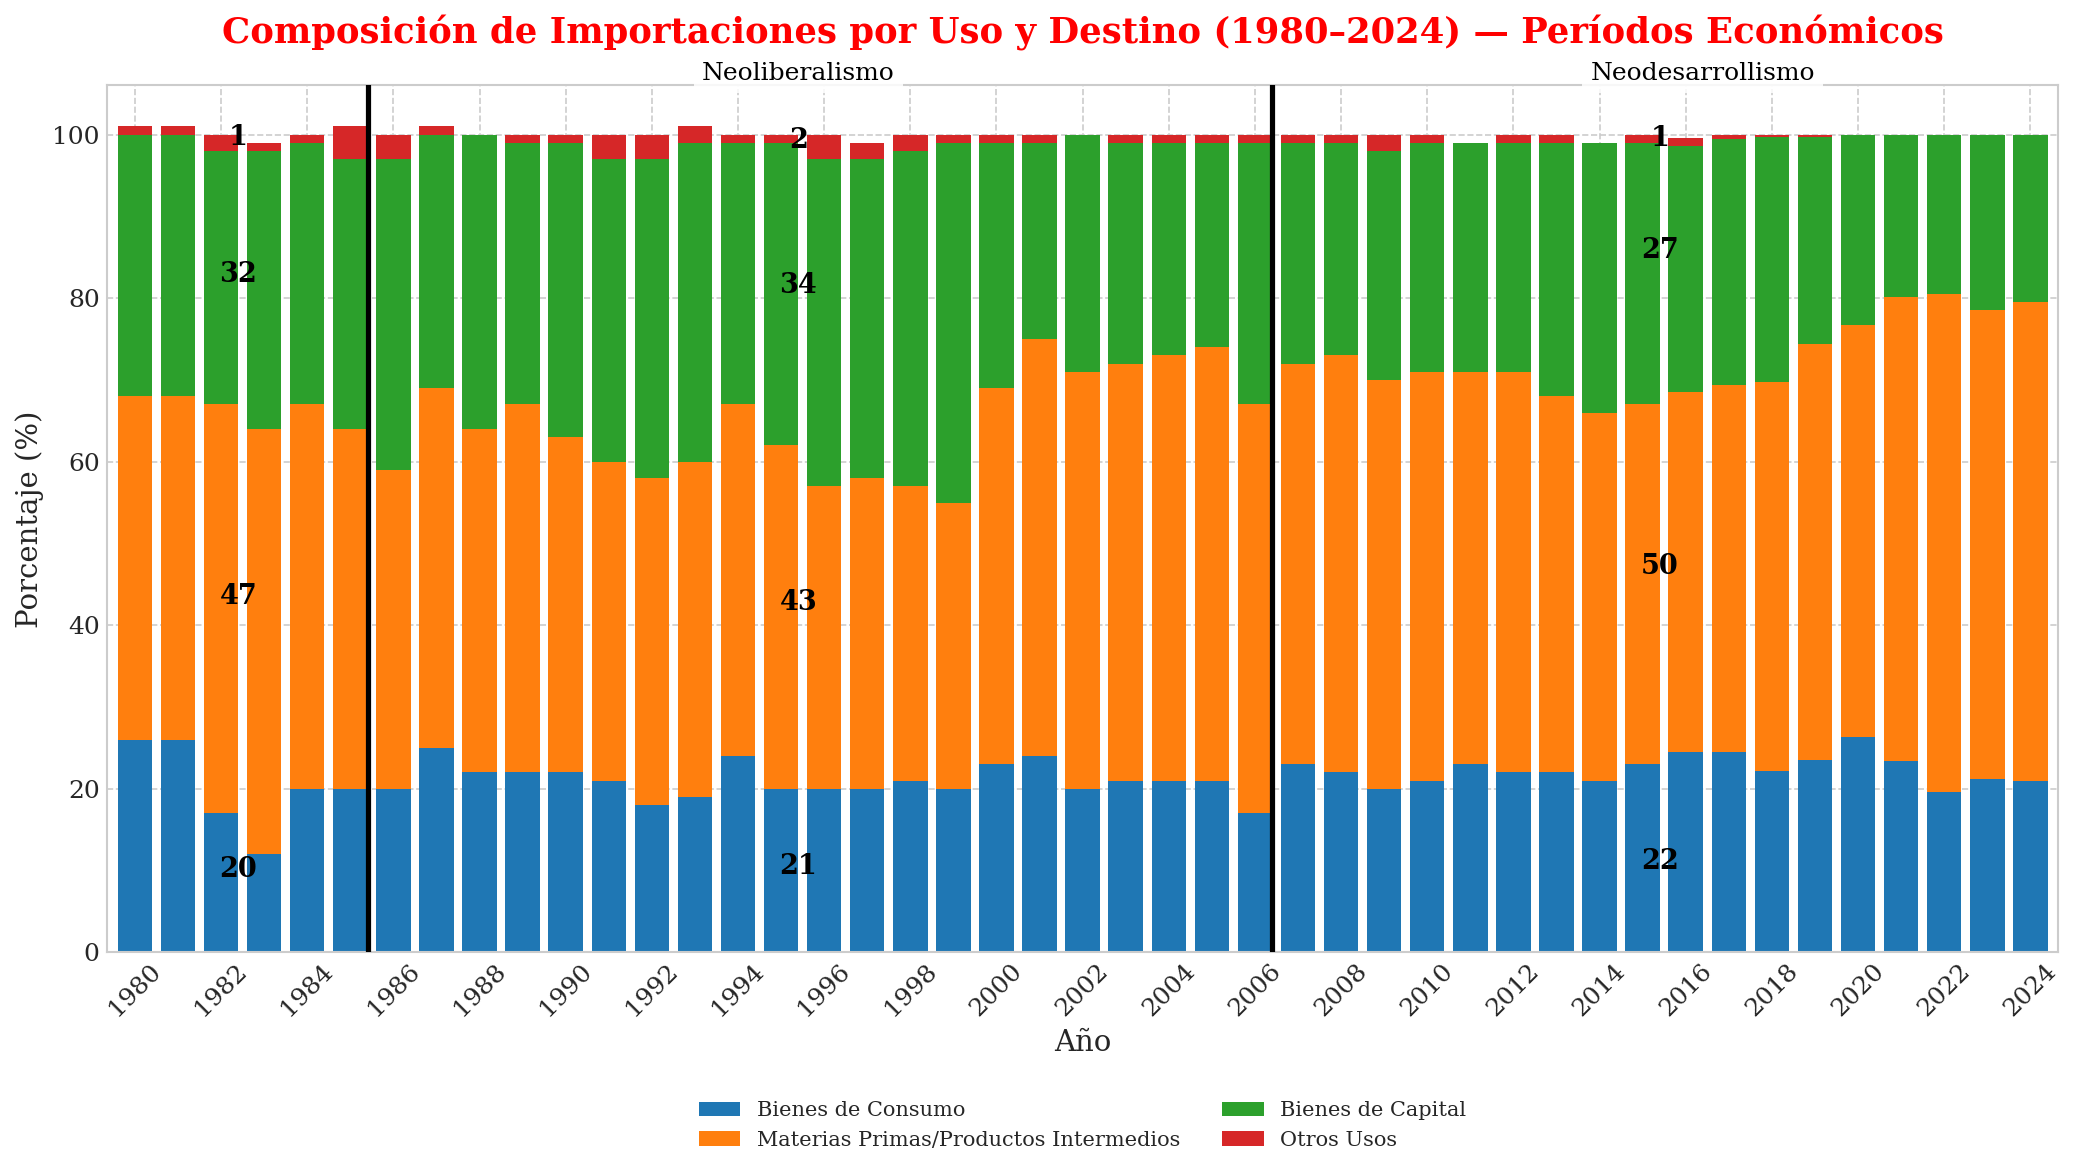

Gráfico de períodos guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/participacion_composicion_importaciones_uso_destino/participacion_composicion_importaciones_uso_destino_periodos.png


In [2]:
# ═══════════════════════════════════════════════════════════════════
# SEGUNDA GRÁFICA: PERÍODOS ESTRUCTURALES - BARPLOT
# ═══════════════════════════════════════════════════════════════════

# Preparación de datos para períodos estructurales
cycles_periodos = adjust_cycles(df, CYCLES_PERIODOS)
cycle_stats_periodos = {
    name: df.loc[sl, cols].mean().to_dict()
    for name, sl in cycles_periodos.items()
}

# Offsets específicos para períodos estructurales
hitos_offset_periodos = {
    1952: (0, 1),
    1985: (0, 1),
    2006: (0, 1),
}

hitos_text_x_periodos = {
    1952: 15,
    1985: 10,
    2006: 10
}

# Offsets para medias por período estructural
MEAN_OFFSETS_BY_NAME_PERIODOS = {

}

# Construcción del gráfico de períodos estructurales
fig, ax = plot_stacked_bar(
    df[cols],
    series=componentes,
    title=f"Composición de Importaciones por Uso y Destino ({df.index.min()}–{df.index.max()}) — Períodos Económicos",
    legend_ncol=2,
    figsize=(14, 8),
    xlabel="Año",
    ylabel="Porcentaje (%)"
)

# Elementos gráficos específicos para períodos
add_hitos_barras(
    ax, 
    df.index,
    hitos_v_periodos,            # Usar hitos de períodos estructurales
    hitos_offset_periodos,
    hitos_text_x_periodos
)

add_cycle_means_barras(
    ax,
    index=list(df.index),
    cycle_slices=cycles_periodos,     # Usar ciclos de períodos estructurales
    cycle_stats=cycle_stats_periodos,
    cols=cols,
    offsets=MEAN_OFFSETS_BY_NAME_PERIODOS,
)

plt.tight_layout()
out_path_periodos = os.path.join(OUTPUT_DIR, "participacion_composicion_importaciones_uso_destino_periodos.png")
plt.savefig(out_path_periodos, dpi=300)
plt.show()
plt.close()

print(f"Gráfico de períodos guardado en: {out_path_periodos}")